# Data Visualization

This notebook focuses on creating various visualizations to better understand the data patterns and relationships.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load data
df = pd.read_csv('../data/Train.csv')
print('Data loaded for visualization')

Data loaded for visualization


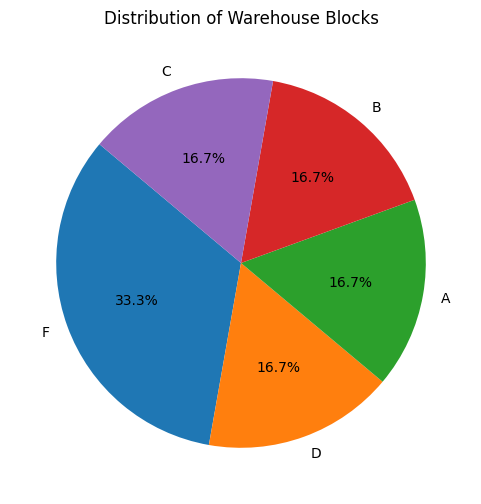

In [2]:
# Pie chart for warehouse blocks
warehouse_counts = df['Warehouse_block'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(warehouse_counts, labels=warehouse_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Warehouse Blocks')
plt.show()

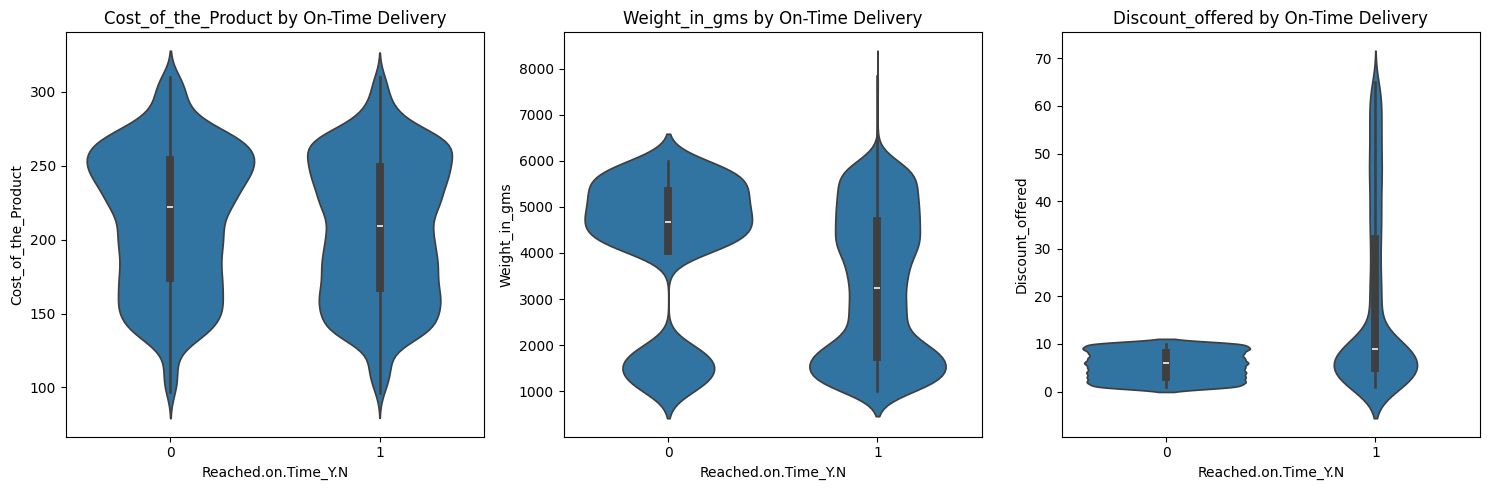

In [3]:
# Violin plots for numerical features by target
numerical_cols = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']
plt.figure(figsize=(15,5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x='Reached.on.Time_Y.N', y=col, data=df)
    plt.title(f'{col} by On-Time Delivery')
plt.tight_layout()
plt.show()

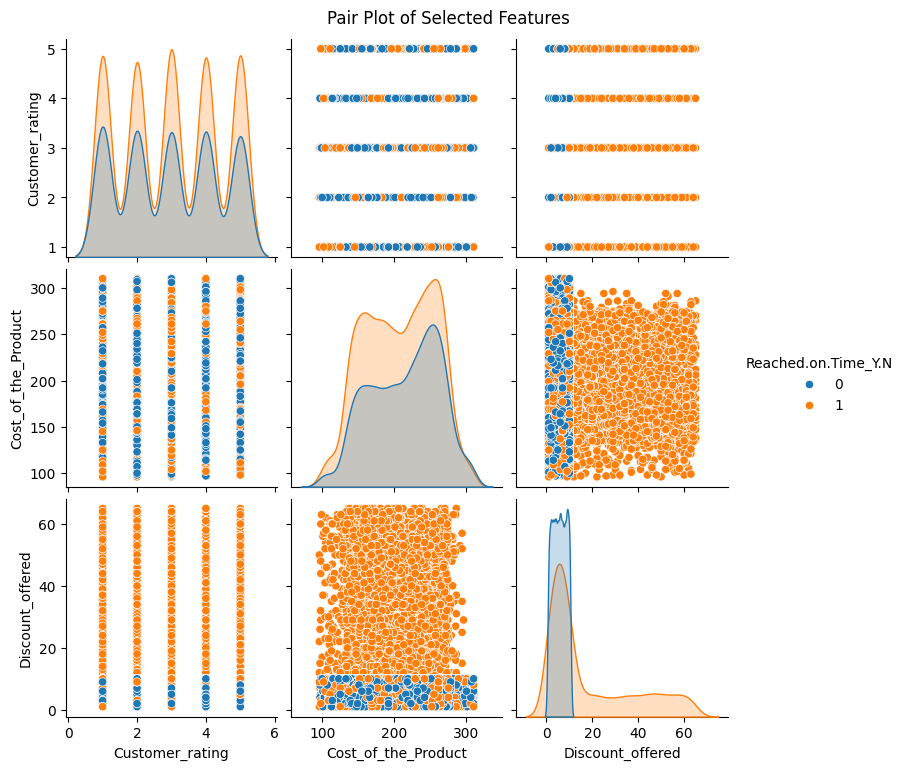

In [4]:
# Pair plot for selected features
selected_cols = ['Customer_rating', 'Cost_of_the_Product', 'Discount_offered', 'Reached.on.Time_Y.N']
sns.pairplot(df[selected_cols], hue='Reached.on.Time_Y.N', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

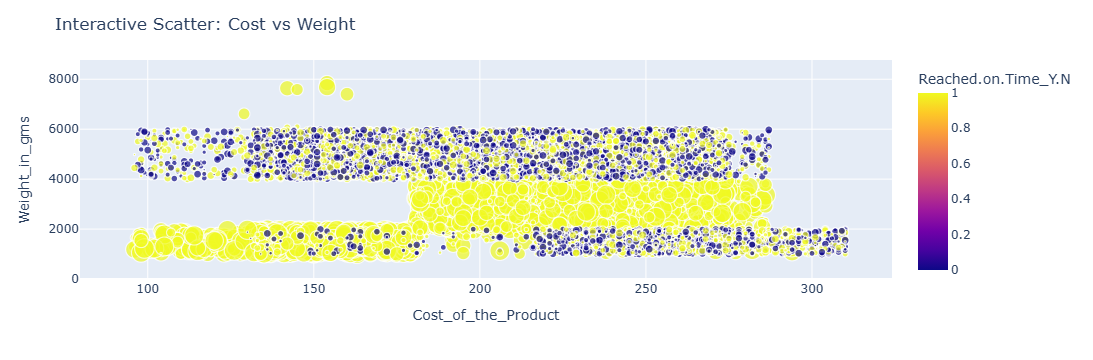

In [5]:
# Interactive plot with Plotly
fig = px.scatter(df, x='Cost_of_the_Product', y='Weight_in_gms', color='Reached.on.Time_Y.N', 
                 size='Discount_offered', hover_data=['Mode_of_Shipment', 'Warehouse_block'])
fig.update_layout(title='Interactive Scatter: Cost vs Weight')
fig.show()

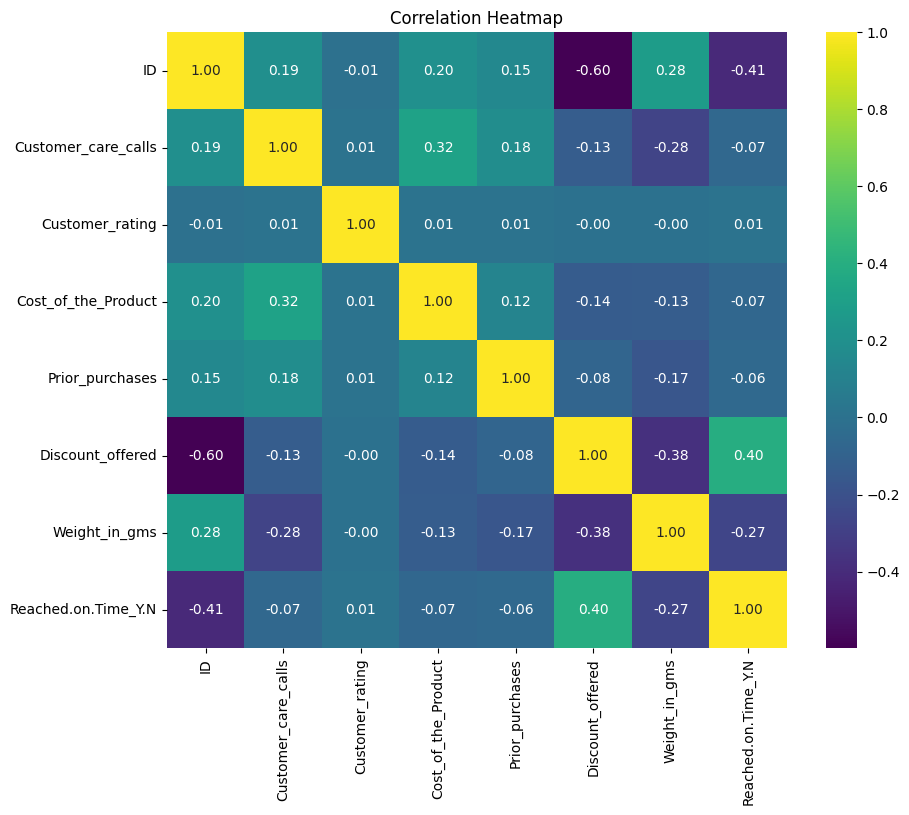

In [6]:
# Heatmap of correlations
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

C:\Users\rithu\AppData\Local\Temp\ipykernel_21952\3314734127.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product_importance', y='Reached.on.Time_Y.N', data=df, ci=None)


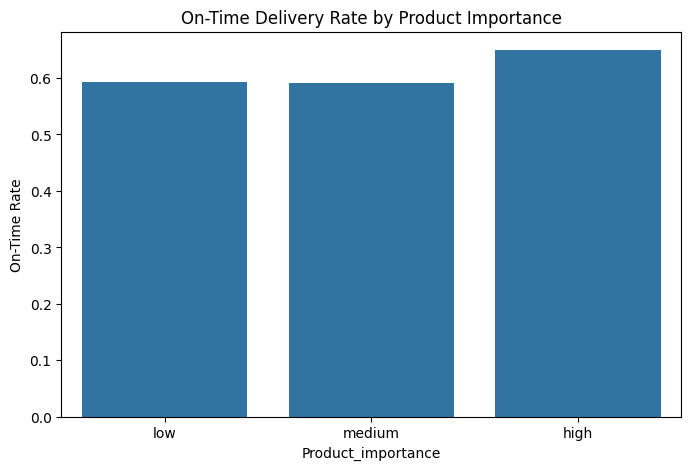

In [7]:
# Bar plot for product importance vs on-time
plt.figure(figsize=(8,5))
sns.barplot(x='Product_importance', y='Reached.on.Time_Y.N', data=df, ci=None)
plt.title('On-Time Delivery Rate by Product Importance')
plt.ylabel('On-Time Rate')
plt.show()